In [1]:
import time
%matplotlib widget

from scipy.constants import hbar, m_e, eV, physical_constants
## necessary modules
import numpy as np
from tqdm import tqdm
from matplotlib.patches import ConnectionPatch
import random
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy import integrate
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
from pfapack.ctypes import pfaffian as cpf
from scipy import sparse
from scipy.linalg import ishermitian
from OneD_nanowire_utils import construct_Hamil, Diagonalize, Energy_spectrum, wavefunc, Energy_spectrum_phi, Energy_spectrum_v_VQD, pfaffian_calculation, Energy_tracker_phi, Energy_tracker_VQD, Topological_stability, Gen_disorder
from transport_quantities_1D_nanowire import capacitance, Capacitance_vs_phi, Capacitance_vs_VQD, inductance, inductance_vs_phi, inductance_vs_VQD
from config_1D_nanowire import ModelParams
import matplotlib.ticker as ticker
from joblib import Parallel, delayed
from copy import deepcopy

## define the pauli matrices
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
s0 = np.array([[1, 0], [0, 1]]) 

In [2]:
V0 = 0.3
disorder_file = "Disorder_N_300_Broy.txt"
V_dis = V0*np.array(np.loadtxt(open(disorder_file, "rb"), skiprows=0))
S = np.array([[0,0,1,0],[0,0,0,1],[1,0,0,0],[0,1,0,0]])
params = ModelParams(Disorder=V_dis, chirality_op=S)

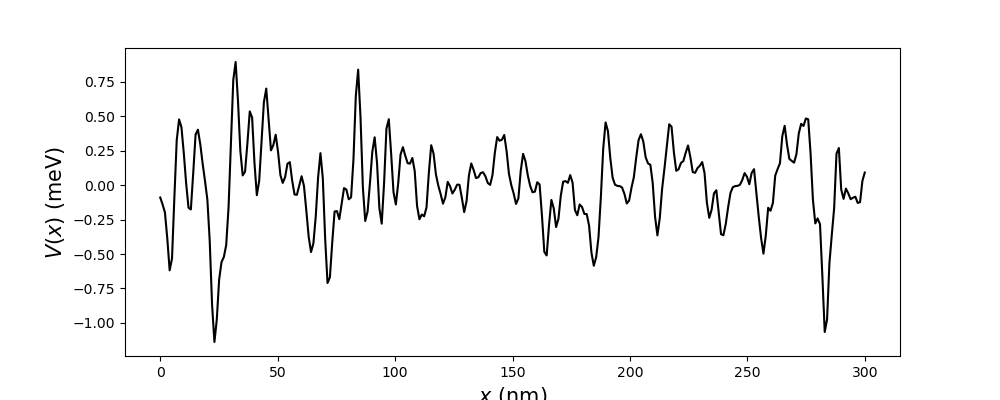

In [3]:
sigma = 70
x0 = 0.0
x1 = params.Length
def Potential(x, V_0):
    return V_0*(
        np.exp(-((int(x/2) - x0) ** 2) / (2 * sigma**2))
        + np.exp(-((x1 - int(x/2)) ** 2) / (2 * sigma**2))
    )

x = np.linspace(0.0,params.Length,params.Length)
pot_V = []
for i in range(0,2*params.Length,2):
    pot_V.append(Potential(i, V0))
pot_V = np.array(pot_V)
#V_dis = pot_V
params = ModelParams(Disorder=V_dis)
fig, ax_v = plt.subplots(figsize=(10, 4))
ax_v.plot(x, params.Disorder, label=r"$V(x)$", color="black")
ax_v.set_xlabel(r"$x$ (nm)", fontsize=15)
ax_v.set_ylabel(r"$V(x)$ (meV)", fontsize=15)
plt.show()

In [180]:
##Local Parameters##
mu_loc = 0.5
Ez_loc = 0.66
V_QD_low_loc = 0.4
V_QD_high_loc = 0.7
V_QD_points_loc = 200
phi_low_loc = 0.0
phi_high_loc = 2.0*np.pi
phi_points_loc = 200
gam_low_loc = 0.0
gam_high_loc = 1.25
gam_points_loc = 200
w_left_loc = 0.025
w_right_loc = 0.025
V_QD_loc = 0.545
No_QD_loc = False
params = ModelParams(
    mu=mu_loc, 
    Ez=Ez_loc, 
    w_left=w_left_loc, 
    w_right=w_right_loc, 
    V_QD_low=V_QD_low_loc, 
    V_QD_high=V_QD_high_loc, 
    V_QD_points=V_QD_points_loc, 
    Ez_low=gam_low_loc, 
    Ez_high=gam_high_loc, 
    Ez_points=gam_points_loc,
    phi_low=phi_low_loc,
    phi_high=phi_high_loc,
    phi_points=phi_points_loc, 
    V_QD=V_QD_loc,
    Disorder=V_dis, 
    chirality_op=S,
                     )
gam_range_loc = np.linspace(gam_low_loc, gam_high_loc, gam_points_loc)
vqd_range_loc = np.linspace(V_QD_low_loc, V_QD_high_loc, V_QD_points_loc)

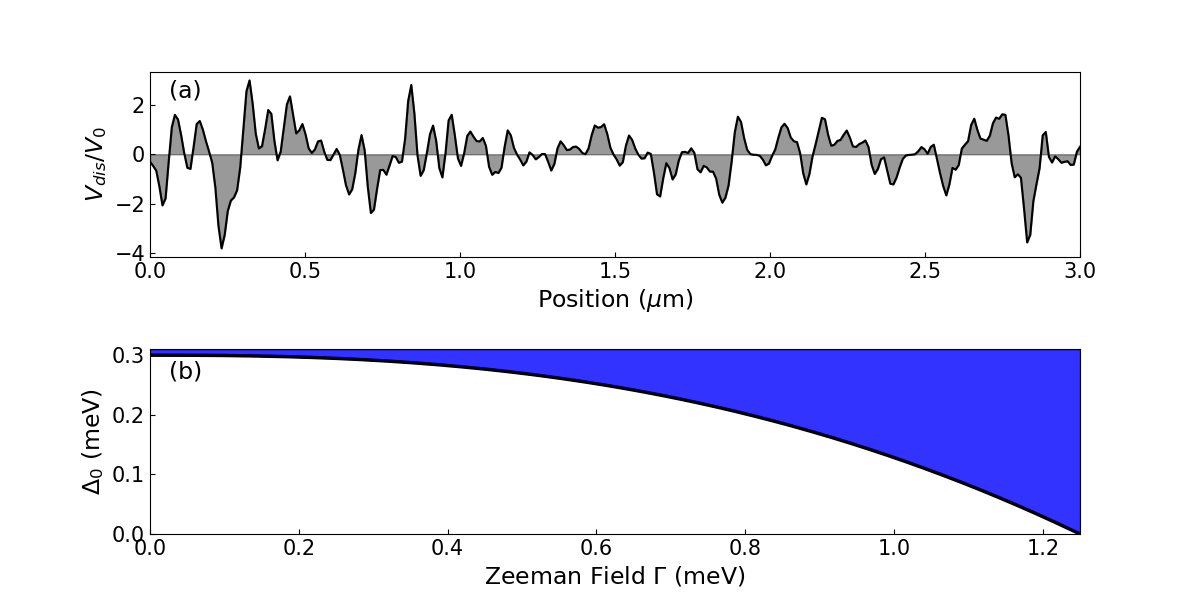

In [70]:
delta_0 = lambda B: 0.3 - 0.17173*(B**2.5)
wire = np.linspace(0.0,3.0,params.Length)

fig = plt.figure(figsize=(12, 6))
gs = GridSpec(2,1, figure=fig, hspace=0.5)

ax_dis = fig.add_subplot(gs[0,0])
ax_dis.plot(wire, V_dis/np.sqrt(np.mean(V_dis**2.0)), '-k', linewidth=1.5)
ax_dis.fill_between(wire, V_dis/np.sqrt(np.mean(V_dis**2.0)), 0.0, color='black', alpha=0.4)
ax_dis.set_ylabel(r"$V_{dis}/V_0$", fontsize=17)
ax_dis.set_xlabel(r"Position ($\mu$m)", fontsize=17)
ax_dis.set_xlim(0.0,3.0)
ax_dis.text(0.02, 0.96, '(a)', transform=ax_dis.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_dis.tick_params(axis='both', which='major', labelsize=15, direction='in')

ax_del = fig.add_subplot(gs[1,0])
ax_del.plot(gam_range_loc, delta_0(gam_range_loc), '-k', linewidth=2.5)
ax_del.fill_between(gam_range_loc, delta_0(gam_range_loc), 0.31, color='blue', alpha=0.8)
ax_del.set_ylabel(r"$\Delta_0$ (meV)", fontsize=17)
ax_del.set_xlabel(r"Zeeman Field $\Gamma$ (meV)", fontsize=17)
ax_del.set_xlim(0.0,1.25)
ax_del.set_ylim(0.0,0.31)
ax_del.text(0.02, 0.94, '(b)', transform=ax_del.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_del.tick_params(axis='both', which='major', labelsize=15, direction='in')

plt.savefig("../Impedance_calc_paper/Plots/Dis_and_delta0_profile.pdf")

In [103]:
def _worker_pf(Ez0, mu_loc, No_QD, params):
    return pfaffian_calculation(mu=mu_loc, Ez=Ez0, No_QD=No_QD, params=deepcopy(params))

def _worker_Ts(Ez0, mu_loc, No_QD, params):
    p = deepcopy(params)
    return Topological_stability(mu=mu_loc, Ez=Ez0, No_QD=No_QD, params=p)

In [181]:
Energy_spectra = Energy_spectrum(mu=mu_loc, params=params, No_QD=True, num_eigvals=100)#np.zeros((50,gam_points_loc))##
#pfaf_1d = Parallel(n_jobs=-1, backend="loky")(
#    delayed(_worker_pf)(Ez0, mu_loc, True, params)
#    for Ez0 in tqdm(gam_range_loc)
#)
Ts_1d = Parallel(n_jobs=-1, backend="loky")(
    delayed(_worker_Ts)(Ez0, mu_loc, False, params)
    for Ez0 in tqdm(gam_range_loc)
)

#c_params = deepcopy(params)
#c_params.V_QD = 0.545
#mf_wf1_tp, mf_wf2_tp, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=No_QD_loc, params=c_params)
#C_vs_phi_even_1, C_vs_phi_odd_1 = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=c_params, number_of_states=200)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
#L_vs_phi_even_P_1, L_vs_phi_even_D_1, L_vs_phi_odd_P_1, L_vs_phi_odd_D_1 = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=c_params, number_of_states=200)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
#Ep_1, En_1 = Energy_tracker_phi(mu=mu_loc, Ez=Ez_loc, params=c_params)

#E_vs_vqd, _, _ = Energy_spectrum_v_VQD(mu=mu_loc, Ez=Ez_loc, phi=0.0, params=params)
#E_vqd_p = deepcopy(params)
#E_vqd_p.V_QD_points = 500
#E_vqd_range = np.linspace(E_vqd_p.V_QD_low, E_vqd_p.V_QD_high, E_vqd_p.V_QD_points)
#Ep_0, En_0 = Energy_tracker_VQD(mu=mu_loc, Ez=Ez_loc, phi0=0.0, params=E_vqd_p)
#Ep_pi, En_pi = Energy_tracker_VQD(mu=mu_loc, Ez=Ez_loc, phi0=np.pi, params=E_vqd_p)
#p_transport = deepcopy(params)
#p_transport.V_QD_low=0.49
#p_transport.V_QD_high=0.62
#vqd_transport_range = np.linspace(p_transport.V_QD_low, p_transport.V_QD_high, p_transport.V_QD_points)
#C_vs_vqd_0, C_vs_vqd_pi = Capacitance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=p_transport, number_of_states=200)
#L_vs_vqd_P_0, L_vs_vqd_D_0, L_vs_vqd_P_pi, L_vs_vqd_D_pi = inductance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=p_transport, number_of_states=200)

100%|██████████| 200/200 [00:26<00:00,  7.69it/s]


In [152]:
c_params = deepcopy(params)
Ez_loc2 = 0.3
c_params.V_QD = 0.545
mf_wf1_tr, mf_wf2_tr, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc2, phi0=0.0, No_QD=No_QD_loc, params=c_params)
C_vs_phi_even_2, C_vs_phi_odd_2 = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc2, params=c_params, number_of_states=200)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
L_vs_phi_even_P_2, L_vs_phi_even_D_2, L_vs_phi_odd_P_2, L_vs_phi_odd_D_2 = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc2, params=c_params, number_of_states=200)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
Ep_2, En_2 = Energy_tracker_phi(mu=mu_loc, Ez=Ez_loc2, params=c_params)

phi eigs: 100%|██████████| 200/200 [00:00<00:00, 64413.79it/s]


In [153]:
mf_wf1_tp, mf_wf2_tp, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=True, params=c_params)
mf_wf1_tr, mf_wf2_tr, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc2, phi0=0.0, No_QD=True, params=c_params)

/var/folders/48/y24539z12pz_600tsnssd6vr0000gn/T/ipykernel_2656/83949577.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


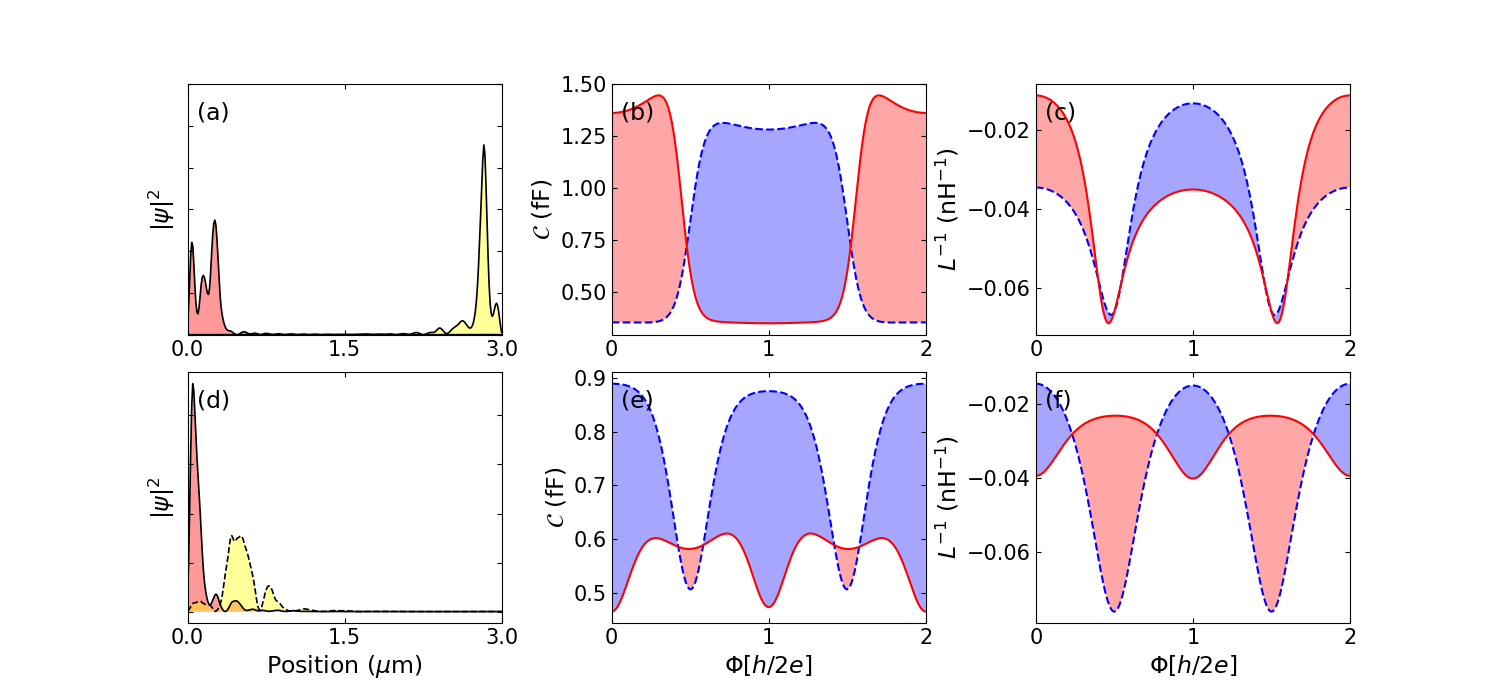

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig = plt.figure(figsize=(15, 7))
gs = GridSpec(2, 3, figure=fig, hspace=0.15, wspace=0.35)

angles = np.linspace(0.0, 2.0, phi_points_loc)
wire   = np.linspace(0.0, 3.0, 300)  # last point is the QD
qd_x   = wire[-1]

# ------------------------------------------------------------------
# Top row: TOPOLOGICAL REGIME
# ------------------------------------------------------------------
ax_wf1 = fig.add_subplot(gs[0, 0])
ax_C1  = fig.add_subplot(gs[0, 1])
ax_L1  = fig.add_subplot(gs[0, 2])

# ---- wavefunction with filled lobes ----
# fill first so lines stay visible on top
ax_wf1.fill_between(wire, 0.0, mf_wf1_tp,
                    where=mf_wf1_tp >= 0,
                    facecolor='red', alpha=0.4, step='mid')
ax_wf1.fill_between(wire, 0.0, mf_wf2_tp,
                    where=mf_wf2_tp >= 0,
                    facecolor='yellow', alpha=0.4, step='mid')

ax_wf1.plot(wire, mf_wf1_tp, color='k', lw=1.2)
ax_wf1.plot(wire, mf_wf2_tp, color='k', lw=1.2)

ax_wf1.set_ylabel(r'$|\psi|^2$', fontsize=17)
ax_wf1.set_xlim(wire[0], wire[-1])
ax_wf1.set_ylim(0.0, 0.12)
ax_wf1.tick_params(labelsize=15, direction='in', top=True, right=True)
ax_wf1.xaxis.set_major_locator(ticker.FixedLocator([0.0,1.5,3.0]))
ax_wf1.set_yticklabels([])

# ---- capacitance with shaded regions between even/odd ----
mask_C1 = C_vs_phi_even_1 >= C_vs_phi_odd_1

ax_C1.fill_between(angles, C_vs_phi_even_1, C_vs_phi_odd_1,
                   where=mask_C1,
                   facecolor='blue', alpha=0.35)
ax_C1.fill_between(angles, C_vs_phi_even_1, C_vs_phi_odd_1,
                   where=~mask_C1,
                   facecolor='red', alpha=0.35)

ax_C1.plot(angles, C_vs_phi_even_1, color='b', lw=1.5, ls='--', label='Even parity')
ax_C1.plot(angles, C_vs_phi_odd_1,  color='r', lw=1.5,          label='Odd parity')

ax_C1.set_ylabel(r'$\mathcal{C}$ (fF)', fontsize=17)
ax_C1.set_xlim(0.0, 2.0)
ax_C1.tick_params(labelsize=15, direction='in', top=True, right=True)
ax_C1.xaxis.set_major_locator(ticker.FixedLocator([0.0,1.0,2.0]))

# ---- L^{-1} with shaded regions between even/odd ----
L_vs_phi_even_1 = L_vs_phi_even_D_1 + L_vs_phi_even_P_1
L_vs_phi_odd_1  = L_vs_phi_odd_D_1  + L_vs_phi_odd_P_1
mask_L1 = L_vs_phi_even_1 >= L_vs_phi_odd_1

ax_L1.fill_between(angles, L_vs_phi_even_1, L_vs_phi_odd_1,
                   where=mask_L1,
                   facecolor='blue', alpha=0.35)
ax_L1.fill_between(angles, L_vs_phi_even_1, L_vs_phi_odd_1,
                   where=~mask_L1,
                   facecolor='red', alpha=0.35)

ax_L1.plot(angles, L_vs_phi_even_1, color='b', lw=1.5, ls='--', label='Even parity')
ax_L1.plot(angles, L_vs_phi_odd_1,  color='r', lw=1.5,          label='Odd parity')

ax_L1.set_ylabel(r'$L^{-1}$ (n$\mathrm{H}^{-1}$)', fontsize=17)
ax_L1.set_xlim(0.0, 2.0)
ax_L1.tick_params(labelsize=15, direction='in', top=True, right=True)
ax_L1.xaxis.set_major_locator(ticker.FixedLocator([0.0,1.0,2.0]))

# ------------------------------------------------------------------
# Bottom row: TRIVIAL REGIME
# ------------------------------------------------------------------
ax_wf2 = fig.add_subplot(gs[1, 0], sharex=ax_wf1)
ax_C2  = fig.add_subplot(gs[1, 1], sharex=ax_C1)
ax_L2  = fig.add_subplot(gs[1, 2], sharex=ax_L1)

# wavefunction with fill_between
ax_wf2.fill_between(wire, 0.0, mf_wf1_tr,
                    where=mf_wf1_tr >= 0,
                    facecolor='red', alpha=0.4, step='mid')
ax_wf2.fill_between(wire, 0.0, mf_wf2_tr,
                    where=mf_wf2_tr >= 0,
                    facecolor='yellow', alpha=0.4, step='mid')

ax_wf2.plot(wire, mf_wf1_tr, color='k', lw=1.2, label='ground state')
ax_wf2.plot(wire, mf_wf2_tr, color='k', lw=1.2, ls='--', label='excited state')

ax_wf2.set_xlabel(r'Position ($\mu$m)', fontsize=17)
ax_wf2.set_ylabel(r'$|\psi|^2$', fontsize=17)
ax_wf2.set_xlim(wire[0], wire[-1])
ax_wf2.tick_params(labelsize=15, direction='in', top=True, right=True)
ax_wf2.set_yticklabels([])

# capacitance shading
mask_C2 = C_vs_phi_even_2 >= C_vs_phi_odd_2
ax_C2.fill_between(angles, C_vs_phi_even_2, C_vs_phi_odd_2,
                   where=mask_C2,
                   facecolor='blue', alpha=0.35)
ax_C2.fill_between(angles, C_vs_phi_even_2, C_vs_phi_odd_2,
                   where=~mask_C2,
                   facecolor='red', alpha=0.35)

ax_C2.plot(angles, C_vs_phi_even_2, color='b', lw=1.5, ls='--', label='Even parity')
ax_C2.plot(angles, C_vs_phi_odd_2,  color='r', lw=1.5,          label='Odd parity')

ax_C2.set_xlabel(r'$\Phi[h/2e]$', fontsize=17)
ax_C2.set_ylabel(r'$\mathcal{C}$ (fF)', fontsize=17)
ax_C2.set_xlim(0.0, 2.0)
ax_C2.tick_params(labelsize=15, direction='in', top=True, right=True)

# L^{-1} shading
L_vs_phi_even_2 = L_vs_phi_even_D_2 + L_vs_phi_even_P_2
L_vs_phi_odd_2  = L_vs_phi_odd_D_2  + L_vs_phi_odd_P_2
mask_L2 = L_vs_phi_even_2 >= L_vs_phi_odd_2

ax_L2.fill_between(angles, L_vs_phi_even_2, L_vs_phi_odd_2,
                   where=mask_L2,
                   facecolor='blue', alpha=0.35)
ax_L2.fill_between(angles, L_vs_phi_even_2, L_vs_phi_odd_2,
                   where=~mask_L2,
                   facecolor='red', alpha=0.35)

ax_L2.plot(angles, L_vs_phi_even_2, color='b', lw=1.5, ls='--', label='Even parity')
ax_L2.plot(angles, L_vs_phi_odd_2,  color='r', lw=1.5,          label='Odd parity')

ax_L2.set_xlabel(r'$\Phi[h/2e]$', fontsize=17)
ax_L2.set_ylabel(r'$L^{-1}$ (n$\mathrm{H}^{-1}$)', fontsize=17)
ax_L2.set_xlim(0.0, 2.0)
ax_L2.tick_params(labelsize=15, direction='in', top=True, right=True)

# ------------------------------------------------------------------
# Panel labels (a)–(f) inside boxes
# ------------------------------------------------------------------
axes = [ax_wf1, ax_C1, ax_L1, ax_wf2, ax_C2, ax_L2]
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for ax, lab in zip(axes, labels):
    ax.text(0.03, 0.93, lab,
            transform=ax.transAxes,
            fontsize=17,
            va='top', ha='left')

plt.tight_layout()

#plt.savefig("../Impedance_calc_paper/Plots/Weakly_dis_V0_03_sys_benchmark_Tp_Tr_regime.pdf")
plt.show()


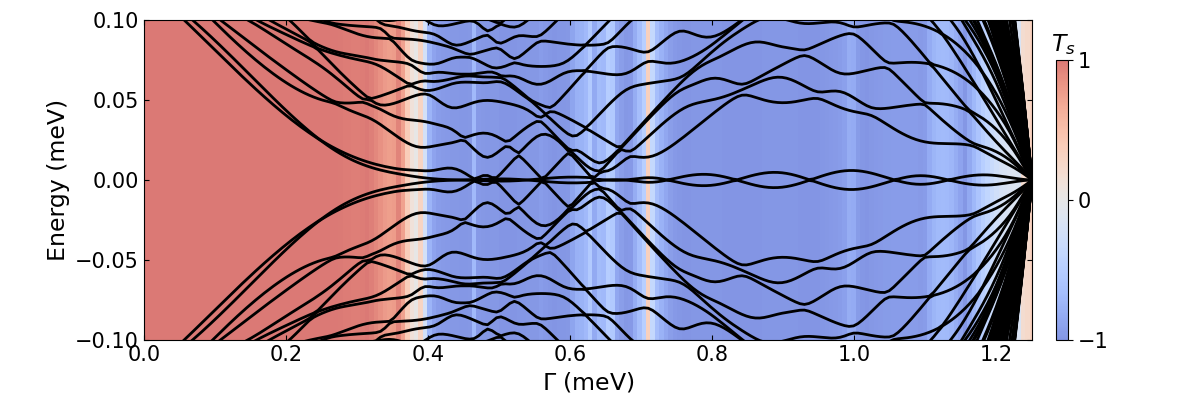

In [ ]:
from matplotlib.colors import TwoSlopeNorm, ListedColormap

fig, ax_E_spec_Ts = plt.subplots(figsize=(12, 4))

# ----------------- background: Ts density -----------------
# energy range to show (slightly padded around spectrum)
Emin = np.min(Energy_spectra)
Emax = np.max(Energy_spectra)
dE   = 0.05 * (Emax - Emin if Emax > Emin else 1.0)

E_vals = np.linspace(Emin - dE, Emax + dE, 300)    # vertical axis grid

# build 2D Ts array: same Ts_1d for all energies (just repeated vertically)
Ts2D = np.tile(Ts_1d, (len(E_vals), 1))            # shape (Ny, Nx)

# nice, trimmed coolwarm colormap, centered at 0
base_cmap = plt.get_cmap("coolwarm")
cmap_Ts   = ListedColormap(base_cmap(np.linspace(0.07, 0.93, 256)))
norm_Ts   = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

pcm = ax_E_spec_Ts.pcolormesh(
    gam_range_loc,
    E_vals,
    Ts2D,
    cmap=cmap_Ts,
    norm=norm_Ts,
    shading="nearest",
    zorder=0,
    alpha=0.7
)

# ----------------- overlay energy spectrum -----------------
ax_E_spec_Ts.plot(
    gam_range_loc,
    Energy_spectra,
    color="k",
    lw=2.0,
    zorder=2
)

# ----------------- axes formatting -----------------
ax_E_spec_Ts.set_xlabel(r"$\Gamma$ (meV)", fontsize=17)
ax_E_spec_Ts.set_ylabel(r"Energy (meV)", fontsize=17)   # change units if needed
ax_E_spec_Ts.tick_params(labelsize=15,
                         direction="in",
                         top=True,
                         right=True)

ax_E_spec_Ts.set_xlim(gam_range_loc[0], gam_range_loc[-1])
ax_E_spec_Ts.set_ylim(-0.1, 0.1)

# ----------------- colorbar for T_s -----------------
plt.subplots_adjust(left=0.12, right=0.86, top=0.95, bottom=0.15)

cax = fig.add_axes([0.88, 0.15, 0.01, 0.70])  # [left, bottom, width, height]
cbar = fig.colorbar(pcm, cax=cax, orientation="vertical")
cbar.set_ticks([-1.0, 0.0, 1.0])
cbar.ax.tick_params(labelsize=15)

# label Ts at the top, vertical (clockwise)
cbar.set_label(r"$T_s$", fontsize=17, rotation=0)
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.tick_right()
cbar.ax.yaxis.set_label_coords(0.6, 1.1)  # tweak if needed

#plt.savefig("../Impedance_calc_paper/Plots/Weakly_dis_V0_03_Energy_spectrum.pdf")

plt.show()


In [ ]:
output_dir = "Paper_result_files/"
np.savetxt(output_dir+"_energy_spectrum_mu_05_Gamma_0_125.txt", Energy_spectra)
np.savetxt(output_dir+"_energy_spectrum_mu_05_pfaffian.txt", np.array(pfaf_1d))
np.savetxt(output_dir+"_energy_versus_VQD_mu_05_Gamma_065.txt", np.array([E_vqd_range, Ep_0, En_0]))
np.savetxt(output_dir+"_delta_capacitance_0_mu_05_Gamma_065.txt", C_vs_vqd_0)
np.savetxt(output_dir+"_delta_capacitance_pi_mu_05_Gamma_065.txt", C_vs_vqd_pi)
np.savetxt(output_dir+"_delta_inductance_P_0_mu_05_Gamma_065.txt", L_vs_vqd_P_0)
np.savetxt(output_dir+"_delta_inductance_D_0_mu_05_Gamma_065.txt", L_vs_vqd_D_0)
np.savetxt(output_dir+"_delta_inductance_P_pi_mu_05_Gamma_065.txt", L_vs_vqd_P_pi)
np.savetxt(output_dir+"_delta_inductance_D_pi_mu_05_Gamma_065.txt", L_vs_vqd_D_pi)

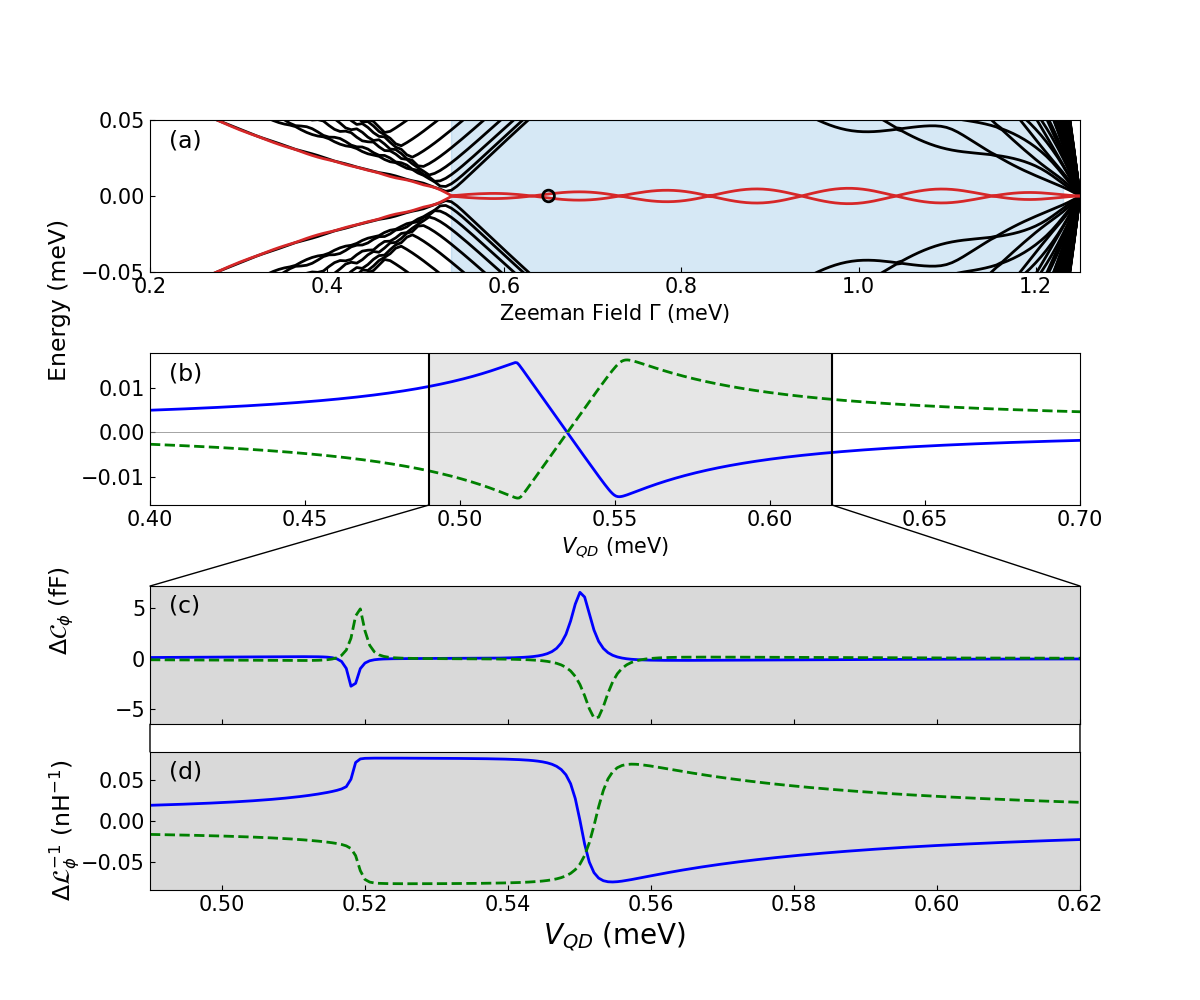

In [ ]:
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(3,1, figure=fig, height_ratios=[1, 1, 2], hspace=0.4)

label_size=15

ax_Espec = fig.add_subplot(gs[0,0])
for i in range(len(Energy_spectra[0])):
        if (i != 49 and i != 50):
                ax_Espec.plot(gam_range_loc, Energy_spectra[:, i], "k", lw=2.0)
ax_Espec.plot(gam_range_loc, Energy_spectra[:, 49], color='#d62728', linestyle='solid', lw=2.0)
ax_Espec.plot(gam_range_loc, Energy_spectra[:, 50],  color='#d62728', linestyle='solid', lw=2.0)
ax_Espec.set_ylim(-0.05,0.05)
ax_Espec.fill_between(gam_range_loc, -0.05, 0.05, where=(np.array(pfaf_1d)<0.0), color='#5DA5DA', alpha=0.25)
ax_Espec.tick_params(axis='both', which='major', labelsize=15, direction='in')
#ax_Espec.set_ylabel("Energy (meV)", fontsize=label_size)
ax_Espec.set_xlabel(r"Zeeman Field $\Gamma$ (meV)", fontsize=label_size)
ax_Espec.text(0.02, 0.94, '(a)', transform=ax_Espec.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Espec.set_xlim(0.2,gam_high_loc)
#ax_Espec.set_title(r"Energy Spectrum for $\mu = $"+str(np.round(mu_loc,2))+" meV")

ax_Espec.scatter(0.65, 0.0, marker="o", s=70.0, facecolors='none' ,edgecolors='black', zorder=2, linewidth=2.0)

ax_Evqd = fig.add_subplot(gs[1,0])
ax_Evqd.plot(E_vqd_range, Ep_0, 'b-', linewidth=2.0)
ax_Evqd.plot(E_vqd_range, En_pi, 'g--', linewidth=2.0)
ax_Evqd.axhline(0, color='gray', linewidth=0.5)
ax_Evqd.axvline(0.49, color='black', linewidth=1.5)
ax_Evqd.axvline(0.62, color='black', linewidth=1.5)
ax_Evqd.axvspan(0.49,0.62, color='0.9', zorder=-1)
#ax_Evqd.set_ylim(-0.05,0.05)
ax_Evqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Evqd.text(0.02, 0.94, '(b)', transform=ax_Evqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
#ax_Evqd.set_ylabel("Energy (meV)", fontsize=label_size)
ax_Evqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size)
ax_Evqd.set_xlim(E_vqd_p.V_QD_low, E_vqd_p.V_QD_high)
#ax_Evqd.set_title(r"Energy versus $V_{QD}$ for $\mu = $"+str(np.round(mu_loc,2))+" meV")

gs_bottom = gridspec.GridSpecFromSubplotSpec(2,1, subplot_spec=gs[2, 0], hspace=0.2)
ax_Cvqd = fig.add_subplot(gs_bottom[0,0])
ax_Cvqd.plot(vqd_transport_range, C_vs_vqd_0, 'b-', linewidth=2.0, label=r"$\phi=0$")
ax_Cvqd.plot(vqd_transport_range, C_vs_vqd_pi, 'g--', linewidth=2.0, label=r"$\phi=\pi$")
#ax_Cvqd.set_ylabel(r"$\Delta \mathcal{C}_\phi$ (fF)", fontsize=label_size+3)
#ax_Cvqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size)
ax_Cvqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Cvqd.text(0.02, 0.94, '(c)', transform=ax_Cvqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Cvqd.set_xlim(p_transport.V_QD_low, p_transport.V_QD_high)
ax_Cvqd.set_facecolor('0.85')

ax_Lvqd = fig.add_subplot(gs_bottom[1,0], sharex=ax_Cvqd)
ax_Lvqd.plot(vqd_transport_range, L_vs_vqd_P_0 + L_vs_vqd_D_0, 'b-', linewidth=2.0, label=r"$\phi=0$")
ax_Lvqd.plot(vqd_transport_range, L_vs_vqd_P_pi + L_vs_vqd_D_pi, 'g--', linewidth=2.0, label=r"$\phi=\pi$")
#ax_Lvqd.set_ylabel(r"$\Delta \mathcal{L}^{-1}_\phi$ (n$\mathrm{H}^{-1}$)", fontsize=label_size+3)
ax_Lvqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size+5)
ax_Lvqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Lvqd.text(0.02, 0.94, '(d)', transform=ax_Lvqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Lvqd.set_xlim(p_transport.V_QD_low, p_transport.V_QD_high)
ax_Lvqd.set_facecolor('0.85')

yl_top = ax_Evqd.get_ylim()
yl_bot1 = ax_Cvqd.get_ylim()
yl_bot2 = ax_Lvqd.get_ylim()

plt.setp(ax_Cvqd.get_xticklabels(), visible=False)
plt.setp(ax_Lvqd.get_xticklabels(), visible=True)

con_left = ConnectionPatch(
        xyA = (0.49, yl_top[0]), coordsA=ax_Evqd.transData,
        xyB = (0.49, yl_bot1[1]), coordsB=ax_Cvqd.transData,
        color='black',
)

con_right = ConnectionPatch(
        xyA = (0.62, yl_top[0]), coordsA=ax_Evqd.transData,
        xyB = (0.62, yl_bot1[1]), coordsB=ax_Cvqd.transData,
        color='black',
)

con_left_2 = ConnectionPatch(
        xyA = (0.49, yl_bot1[0]), coordsA=ax_Cvqd.transData,
        xyB = (0.49, yl_bot2[1]), coordsB=ax_Lvqd.transData,
        color='black',
)

con_right_2 = ConnectionPatch(
        xyA = (0.62, yl_bot1[0]), coordsA=ax_Cvqd.transData,
        xyB = (0.62, yl_bot2[1]), coordsB=ax_Lvqd.transData,
        color='black',
)

fig.text(0.04, 0.7, "Energy (meV)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.39, r"$\Delta \mathcal{C}_\phi$ (fF)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.17, r"$\Delta \mathcal{L}^{-1}_\phi$ (n$\mathrm{H}^{-1}$)", rotation="vertical", va="center", fontsize=17)
fig.add_artist(con_left)
fig.add_artist(con_right)
fig.add_artist(con_left_2)
fig.add_artist(con_right_2)

#plt.savefig("../Impedance_calc_paper/Plots/Clean_sys_energy_and_transport_TpRegime.pdf")

plt.show()

In [ ]:
output_dir = "Paper_result_files/"
np.savetxt(output_dir+"_energy_versus_phi_vqd_551_mu_05_Gamma_065.txt", np.array([Ep_1, En_1]))
np.savetxt(output_dir+"_energy_versus_phi_vqd_512_mu_05_Gamma_065.txt", np.array([Ep_2, En_2]))
np.savetxt(output_dir+"_delta_capacitance_versus_phi_551_mu_05_Gamma_065.txt", np.array([C_vs_phi_even_1, C_vs_phi_odd_1]))
np.savetxt(output_dir+"_delta_capacitance_versus_phi_512_mu_05_Gamma_065.txt", np.array([C_vs_phi_even_2, C_vs_phi_odd_2]))
np.savetxt(output_dir+"_delta_inductance_versus_phi_P_551_mu_05_Gamma_065.txt", np.array([L_vs_phi_even_P_1, L_vs_phi_odd_P_1]))
np.savetxt(output_dir+"_delta_inductance_versus_phi_D_551_mu_05_Gamma_065.txt", np.array([L_vs_phi_even_D_1, L_vs_phi_odd_D_1]))
np.savetxt(output_dir+"_delta_inductance_versus_phi_P_512_mu_05_Gamma_065.txt", np.array([L_vs_phi_even_P_2, L_vs_phi_odd_P_2]))
np.savetxt(output_dir+"_delta_inductance_versus_phi_D_512_mu_05_Gamma_065.txt", np.array([L_vs_phi_even_D_2, L_vs_phi_odd_D_2]))

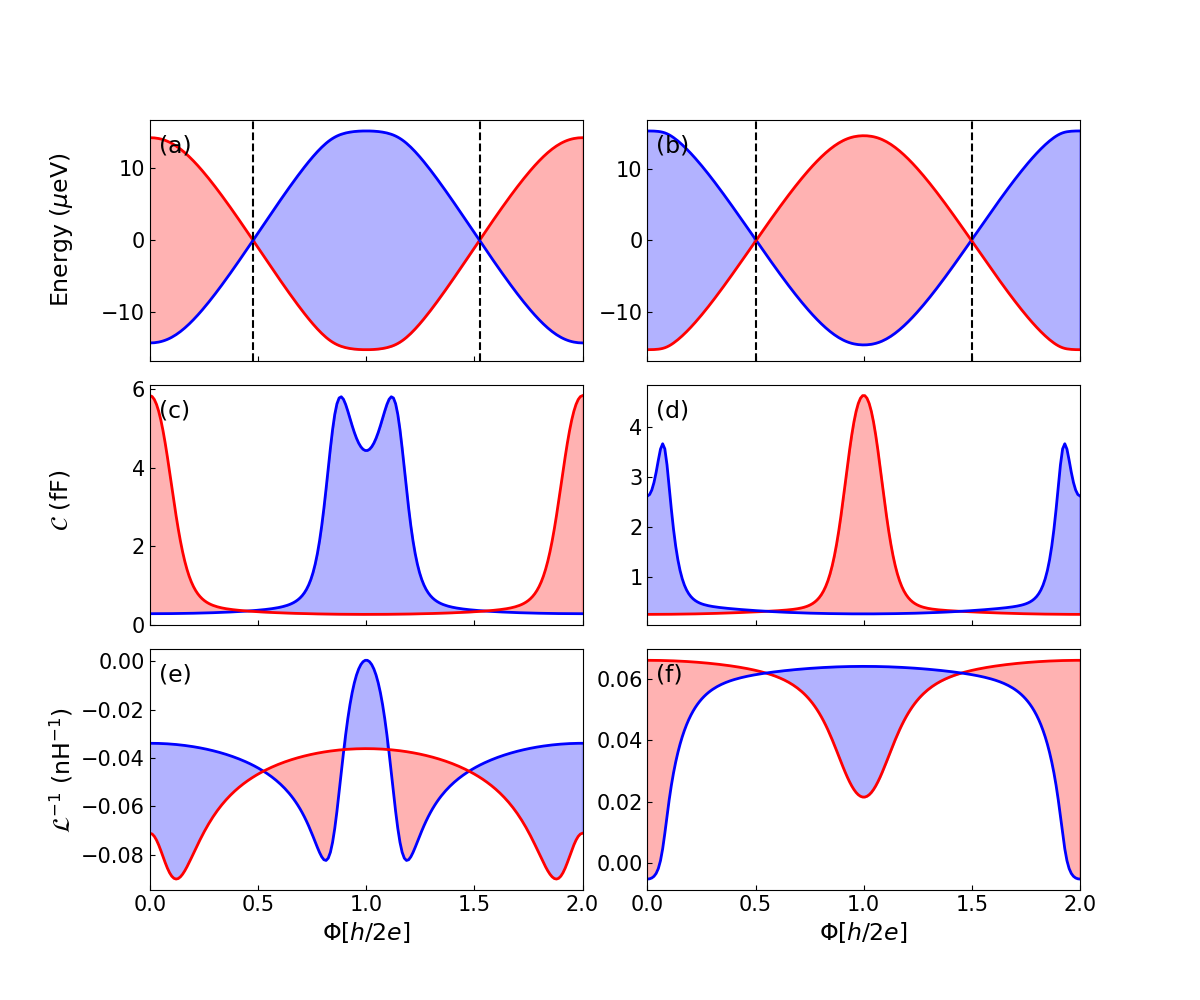

In [159]:
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(3,2, figure=fig, hspace=0.1, wspace=0.15)

angles = np.linspace(0.0, 2.0, phi_points_loc)

#Ep_1, En_1, Ep_2, En_2 = Ep_1/1000.0, En_1/1000.0, Ep_2/1000.0, En_2/1000.0

ax_Evphi_1 = fig.add_subplot(gs[0,0])
ax_Evphi_1.plot(angles, Ep_1, 'r-', lw=2.0)
ax_Evphi_1.plot(angles, En_1, 'b-', lw=2.0)
ax_Evphi_1.fill_between(angles, Ep_1, En_1, where=(Ep_1>0.0), color='red', alpha=0.3)
ax_Evphi_1.fill_between(angles, Ep_1, En_1, where=(En_1>0.0), color='blue', alpha=0.3)
ax_Evphi_1.axvline(1.4968/np.pi, linestyle='dashed', color='black')
ax_Evphi_1.axvline(4.7863/np.pi, linestyle='dashed', color='black')
ax_Evphi_1.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Evphi_1.text(0.02, 0.94, '(a)', transform=ax_Evphi_1.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Evphi_1.set_xlim(0.0,2.0)

ax_Evphi_2 = fig.add_subplot(gs[0,1])
ax_Evphi_2.plot(angles, Ep_2, 'b-', lw=2.0)
ax_Evphi_2.plot(angles, En_2, 'r-', lw=2.0)
ax_Evphi_2.fill_between(angles, Ep_2, En_2, where=(Ep_2>0.0), color='blue', alpha=0.3)
ax_Evphi_2.fill_between(angles, Ep_2, En_2, where=(En_2>0.0), color='red', alpha=0.3)
ax_Evphi_2.axvline(0.5, linestyle='dashed', color='black')
ax_Evphi_2.axvline(1.5, linestyle='dashed', color='black')
ax_Evphi_2.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Evphi_2.text(0.02, 0.94, '(b)', transform=ax_Evphi_2.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Evphi_2.set_xlim(0.0,2.0)

ax_Cvphi_1 = fig.add_subplot(gs[1,0])
ax_Cvphi_1.plot(angles, C_vs_phi_even_1, 'b-', lw=2.0)
ax_Cvphi_1.plot(angles, C_vs_phi_odd_1, 'r-', lw=2.0)
ax_Cvphi_1.fill_between(angles, C_vs_phi_even_1, C_vs_phi_odd_1, where=(C_vs_phi_even_1<C_vs_phi_odd_1), color='red', alpha=0.3)
ax_Cvphi_1.fill_between(angles, C_vs_phi_even_1, C_vs_phi_odd_1, where=(C_vs_phi_even_1>C_vs_phi_odd_1), color='blue', alpha=0.3)
ax_Cvphi_1.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Cvphi_1.text(0.02, 0.94, '(c)', transform=ax_Cvphi_1.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Cvphi_1.set_xlim(0.0,2.0)

ax_Cvphi_2 = fig.add_subplot(gs[1,1])
ax_Cvphi_2.plot(angles, C_vs_phi_even_2, 'r-', lw=2.0)
ax_Cvphi_2.plot(angles, C_vs_phi_odd_2, 'b-', lw=2.0)
ax_Cvphi_2.fill_between(angles, C_vs_phi_even_2, C_vs_phi_odd_2, where=(C_vs_phi_even_2>C_vs_phi_odd_2), color='red', alpha=0.3)
ax_Cvphi_2.fill_between(angles, C_vs_phi_even_2, C_vs_phi_odd_2, where=(C_vs_phi_even_2<C_vs_phi_odd_2), color='blue', alpha=0.3)
ax_Cvphi_2.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Cvphi_2.text(0.02, 0.94, '(d)', transform=ax_Cvphi_2.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Cvphi_2.set_xlim(0.0,2.0)

L_vs_phi_even_1 = L_vs_phi_even_P_1 + L_vs_phi_even_D_1
L_vs_phi_odd_1 = L_vs_phi_odd_P_1 + L_vs_phi_odd_D_1

ax_Lvphi_1 = fig.add_subplot(gs[2,0])
ax_Lvphi_1.plot(angles, L_vs_phi_even_1, 'b-', lw=2.0)
ax_Lvphi_1.plot(angles, L_vs_phi_odd_1, 'r-', lw=2.0)
ax_Lvphi_1.fill_between(angles, L_vs_phi_even_1, L_vs_phi_odd_1, where=(L_vs_phi_even_1<L_vs_phi_odd_1), color='red', alpha=0.3)
ax_Lvphi_1.fill_between(angles, L_vs_phi_even_1, L_vs_phi_odd_1, where=(L_vs_phi_even_1>L_vs_phi_odd_1), color='blue', alpha=0.3)
ax_Lvphi_1.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Lvphi_1.text(0.02, 0.94, '(e)', transform=ax_Lvphi_1.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Lvphi_1.set_xlim(0.0,2.0)
ax_Lvphi_1.set_xlabel(r"$\Phi [h/2e]$", fontsize=17)

L_vs_phi_even_2 = L_vs_phi_even_P_2 + L_vs_phi_even_D_2
L_vs_phi_odd_2 = L_vs_phi_odd_P_2 + L_vs_phi_odd_D_2

ax_Lvphi_2 = fig.add_subplot(gs[2,1])
ax_Lvphi_2.plot(angles, L_vs_phi_even_2, 'r-', lw=2.0)
ax_Lvphi_2.plot(angles, L_vs_phi_odd_2, 'b-', lw=2.0)
ax_Lvphi_2.fill_between(angles, L_vs_phi_even_2, L_vs_phi_odd_2, where=(L_vs_phi_even_2>L_vs_phi_odd_2), color='red', alpha=0.3)
ax_Lvphi_2.fill_between(angles, L_vs_phi_even_2, L_vs_phi_odd_2, where=(L_vs_phi_even_2<L_vs_phi_odd_2), color='blue', alpha=0.3)
ax_Lvphi_2.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Lvphi_2.text(0.02, 0.94, '(f)', transform=ax_Lvphi_2.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Lvphi_2.set_xlim(0.0,2.0)
ax_Lvphi_2.set_xlabel(r"$\Phi [h/2e]$", fontsize=17)

plt.setp(ax_Evphi_1.get_xticklabels(), visible=False)
plt.setp(ax_Evphi_2.get_xticklabels(), visible=False)
plt.setp(ax_Cvphi_1.get_xticklabels(), visible=False)
plt.setp(ax_Cvphi_2.get_xticklabels(), visible=False)
plt.setp(ax_Lvphi_1.get_xticklabels(), visible=True)
plt.setp(ax_Lvphi_2.get_xticklabels(), visible=True)

fig.text(0.04, 0.77, r"Energy ($\mu$eV)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.5, r"$\mathcal{C}$ (fF)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.23, r"$\mathcal{L}^{-1}$ (n$\mathrm{H}^{-1}$)", rotation="vertical", va="center", fontsize=17)

plt.savefig("../Impedance_calc_paper/Plots/Clean_sys_transport_vqds_TpRegime.pdf")

plt.show()

In [36]:
##Generate txt file
C_vs_phi_even, C_vs_phi_odd = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
L_vs_phi_even_P, L_vs_phi_even_D, L_vs_phi_odd_P, L_vs_phi_odd_D = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
##---With QD couplings---##
Energy_spectra = Energy_spectrum(mu=mu_loc, params=params, No_QD=False)
pfaf_1d = np.zeros(gam_points_loc)
for idx in tqdm(range(gam_points_loc)):
    pfaf_1d[idx] = pfaffian_calculation(mu=mu_loc, Ez=gam_range_loc[idx], No_QD=False, params=params)
mf_wf1, mf_wf2, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=False, params=params)
E_vs_phi, _, _ = Energy_spectrum_phi(mu=mu_loc, Ez=Ez_loc, params=params, No_QD=False)
##Saving results with QD included-
parameter_value = "wd_mu_05_gam_065"
np.savetxt("Impedance_calc_files/Energy_spectra_w_QD_"+parameter_value+".txt",Energy_spectra)
np.savetxt("Impedance_calc_files/Pfafian_spectra_w_QD_"+parameter_value+".txt",pfaf_1d)
np.savetxt("Impedance_calc_files/E_vs_phi_w_QD_"+parameter_value+".txt",E_vs_phi)
np.savetxt("Impedance_calc_files/Wavefunction_1_w_QD_"+parameter_value+".txt",mf_wf1)
np.savetxt("Impedance_calc_files/Wavefunction_2_w_QD_"+parameter_value+".txt",mf_wf2)
##---Without QD couplings---##
Energy_spectra = Energy_spectrum(mu=mu_loc, params=params, No_QD=True)
pfaf_1d = np.zeros(gam_points_loc)
for idx in tqdm(range(gam_points_loc)):
    pfaf_1d[idx] = pfaffian_calculation(mu=mu_loc, Ez=gam_range_loc[idx], No_QD=True, params=params)
mf_wf1, mf_wf2, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=True, params=params)
E_vs_phi, _, _ = Energy_spectrum_phi(mu=mu_loc, Ez=Ez_loc, params=params, No_QD=True, end_hopping=True)
##Saving results without QD included-
np.savetxt("Impedance_calc_files/Energy_spectra_wo_QD_"+parameter_value+".txt",Energy_spectra)
np.savetxt("Impedance_calc_files/Pfafian_spectra_wo_QD_"+parameter_value+".txt",pfaf_1d)
np.savetxt("Impedance_calc_files/E_vs_phi_wo_QD_"+parameter_value+".txt",E_vs_phi)
np.savetxt("Impedance_calc_files/Wavefunction_1_wo_QD_"+parameter_value+".txt",mf_wf1)
np.savetxt("Impedance_calc_files/Wavefunction_2_wo_QD_"+parameter_value+".txt",mf_wf2)
##Common calculations
C_vs_VQD_phi_0, C_vs_VQD_phi_pi = Capacitance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
L_vs_VQD_phi_P_0, L_vs_VQD_phi_D_0, L_vs_VQD_phi_P_pi, L_vs_VQD_phi_D_pi = inductance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
##Saving common files
np.savetxt("Impedance_calc_files/Capacitance_even_"+parameter_value+".txt",C_vs_phi_even)
np.savetxt("Impedance_calc_files/Capacitance_odd_"+parameter_value+".txt",C_vs_phi_odd)
np.savetxt("Impedance_calc_files/Capacitance_v_VQD_phi_0_"+parameter_value+".txt",C_vs_VQD_phi_0)
np.savetxt("Impedance_calc_files/Capacitance_v_VQD_phi_pi_"+parameter_value+".txt",C_vs_VQD_phi_pi)
np.savetxt("Impedance_calc_files/Impedance_even_D_"+parameter_value+".txt",L_vs_phi_even_D)
np.savetxt("Impedance_calc_files/Impedance_even_P_"+parameter_value+".txt",L_vs_phi_even_P)
np.savetxt("Impedance_calc_files/Impedance_odd_D_"+parameter_value+".txt",L_vs_phi_odd_D)
np.savetxt("Impedance_calc_files/Impedance_odd_P_"+parameter_value+".txt",L_vs_phi_odd_P)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_0_D_"+parameter_value+".txt",L_vs_VQD_phi_D_0)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_0_P_"+parameter_value+".txt",L_vs_VQD_phi_P_0)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_pi_D_"+parameter_value+".txt",L_vs_VQD_phi_D_pi)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_pi_P_"+parameter_value+".txt",L_vs_VQD_phi_P_pi)

100%|██████████| 150/150 [06:10<00:00,  2.47s/it]


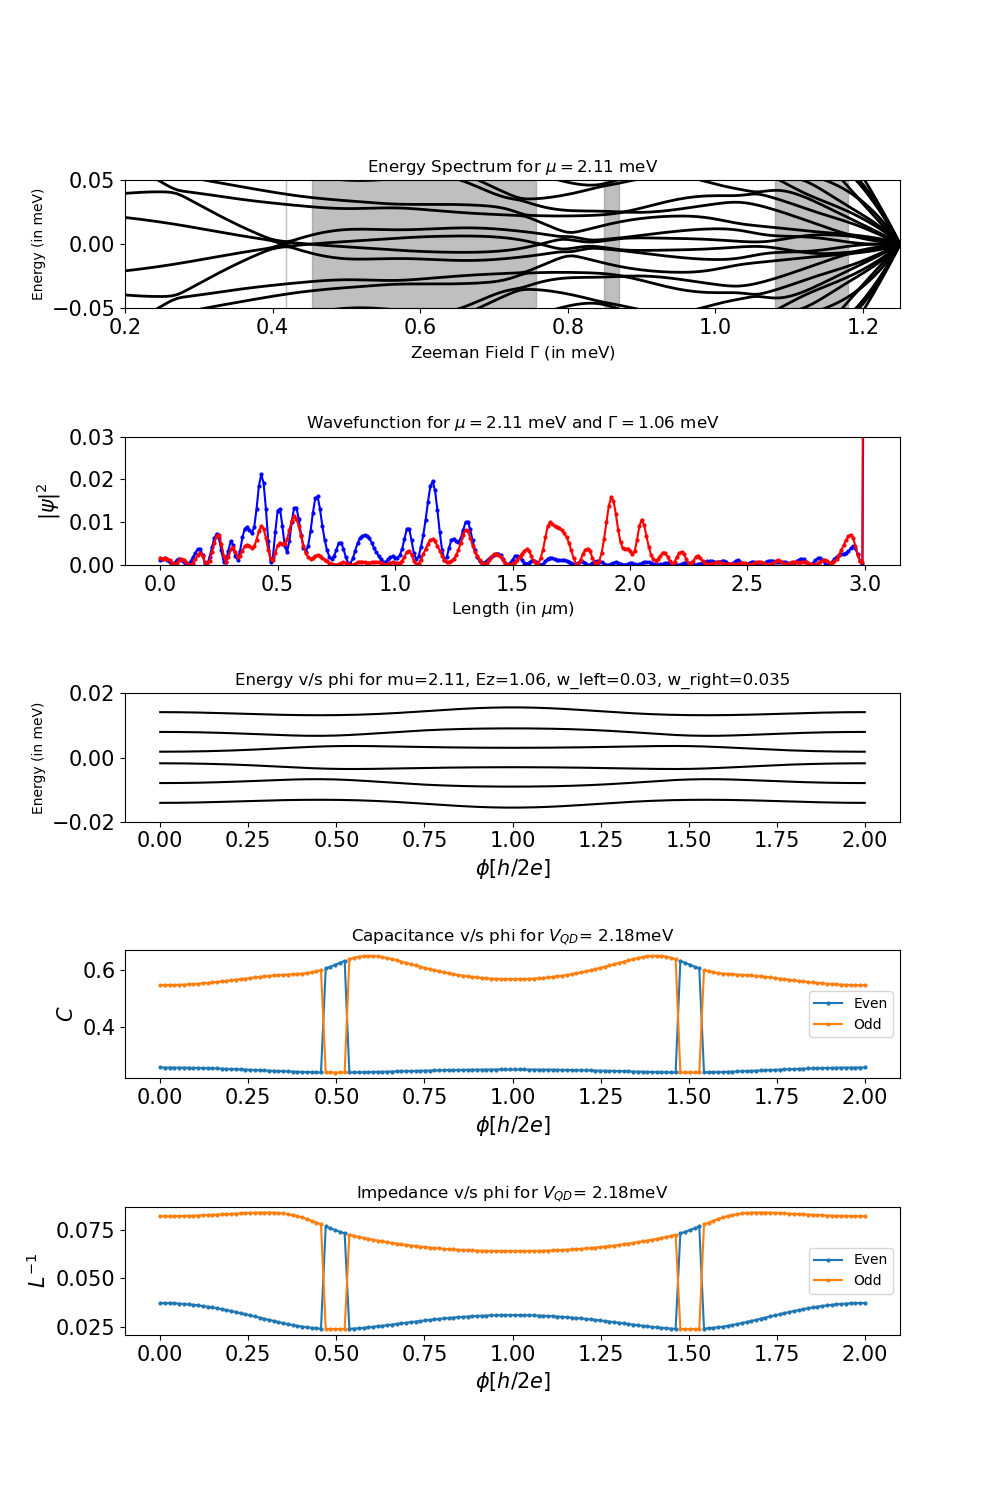

In [59]:
##Plotting all quantities together
fig = plt.figure(figsize=(10, 15))
gs = GridSpec(5,1, figure=fig, hspace=1.)

local_length = params.Length
if not No_QD_loc:
        local_length = params.Length + 1
wire_length = np.linspace(0.0,3.0,local_length)
#angles = np.linspace(params.phi_low, params.phi_high, params.phi_points)
angles = np.linspace(0.0, 2.0, params.phi_points)

ax1 = fig.add_subplot(gs[0,0])
for i in range(len(Energy_spectra[0])):
        ax1.plot(gam_range_loc, Energy_spectra[:, i], "k", lw=2.0)
ax1.set_ylim(-0.05,0.05)
ax1.fill_between(gam_range_loc, -0.05, 0.05, where=(pfaf_1d<0.0), color='gray', alpha=0.5)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax1.set_ylabel("Energy (in meV)")
ax1.set_xlabel(r"Zeeman Field $\Gamma$ (in meV)", fontsize=12)
ax1.set_xlim(gam_low_loc,gam_high_loc)
ax1.set_title(r"Energy Spectrum for $\mu = $"+str(np.round(mu_loc,2))+" meV")

ax2 = fig.add_subplot(gs[1,0])
ax2.plot(wire_length, mf_wf1, 'o-', color='blue', markersize=2.0)
ax2.plot(wire_length, mf_wf2, 'o-', color='red', markersize=2.0)
ax2.set_ylim(0.0, 0.03)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.set_ylabel(r"$\vert\psi\vert^2$", fontsize=15)
ax2.set_xlabel(r"Length (in $\mu$m)", fontsize=12)
ax2.set_title(r"Wavefunction for $\mu = $"+str(np.round(mu_loc,2))+r" meV and $\Gamma = $"+str(np.round(Ez_loc,2))+" meV")

ax3e = fig.add_subplot(gs[2,0])
for i in range(len(E_vs_phi[0])):
        ax3e.plot(angles, E_vs_phi[:, i], "k", lw=1.5)
ax3e.set_ylim(-0.02,0.02)
ax3e.tick_params(axis='both', which='major', labelsize=15)
ax3e.set_ylabel(r"Energy (in meV)")
ax3e.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax3e.set_title(f"Energy v/s phi for mu={mu_loc}, Ez={Ez_loc}, w_left={w_left_loc}, w_right={w_right_loc}")

#Add parity resolved arrays
angle_1 = 0.4595#0.41
angle_2 = 0.5297
angle_3 = 1.4674
angle_4 = 1.5366#1.59
condition_switch = lambda i: False#((angles[i]>=angle_1) and (angles[i]<=angle_4))
condition_double = lambda i: ((angles[i]>=angle_1 and angles[i]<=angle_2) or (angles[i]>=angle_3 and angles[i]<=angle_4))
Ce_parity_resolved, Co_parity_resolved = np.zeros_like(C_vs_phi_even), np.zeros_like(C_vs_phi_odd)
for i in range(len(C_vs_phi_even)):
        Ce_parity_resolved[i] = C_vs_phi_odd[i] if condition_double(i) else C_vs_phi_even[i]
        Co_parity_resolved[i] = C_vs_phi_even[i] if condition_double(i) else C_vs_phi_odd[i]
ax4 = fig.add_subplot(gs[3,0])
ax4.plot(angles, Ce_parity_resolved, '-o', label='Even', markersize=2.0)
ax4.plot(angles, Co_parity_resolved, '-o', label='Odd', markersize=2.0)
ax4.tick_params(axis='both', which='major', labelsize=15)
ax4.set_title(r"Capacitance v/s phi for $V_{QD}$= "+str(np.round(V_QD_loc,2))+"meV")
ax4.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax4.set_ylabel(r'$C$', fontsize=15)
ax4.legend()


#Add parity resolved arrays
#angle_1 = 0.3
#angle_2 = 0.633
#angle_3 = 1.371
#angle_4 = 1.696
condition_switch = lambda i: False#((angles[i]>=angle_1) and (angles[i]<=angle_4))
condition_double = lambda i: ((angles[i]>=angle_1 and angles[i]<=angle_2) or (angles[i]>=angle_3 and angles[i]<=angle_4))
Le_parity_resolved, Lo_parity_resolved = np.zeros_like(L_vs_phi_even_P), np.zeros_like(L_vs_phi_odd_P)
for i in range(len(C_vs_phi_even)):
        Le_parity_resolved[i] = L_vs_phi_odd_P[i] + L_vs_phi_odd_D[i] if condition_double(i) else L_vs_phi_even_P[i] + L_vs_phi_even_D[i]
        Lo_parity_resolved[i] = L_vs_phi_even_P[i] + L_vs_phi_even_D[i] if condition_double(i) else L_vs_phi_odd_P[i] + L_vs_phi_odd_D[i]
ax5 = fig.add_subplot(gs[4,0])
"""
ax5.plot(vqd, d_C0)
ax5.plot(vqd, d_Cpi)
ax5.tick_params(axis = 'both', labelsize=15)
ax5.set_xlabel(r'$V_{QD} (meV)$', fontsize=15)
ax5.set_ylabel(r'$C$', fontsize=15)
#"""
ax5.plot(angles, Le_parity_resolved, '-o', label='Even', markersize=2.0)
ax5.plot(angles, Lo_parity_resolved, '-o', label='Odd', markersize=2.0)
#ax5.plot(VQD_range, L0, label='L0')
#ax5.plot(VQD_range, LPI, label='Lpi')
ax5.tick_params(axis='both', which='major', labelsize=15)
ax5.set_title(r"Impedance v/s phi for $V_{QD}$= "+str(np.round(V_QD_loc,2))+"meV")
ax5.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax5.set_ylabel(r'$L^{-1}$', fontsize=15)
ax5.legend()

#plt.savefig("transport_plots_sanity_checked/Double_crossing_system_profile_mu_22_gamma_0975.pdf")
plt.show()

In [48]:
Delta_C_dens = []
Delta_L_dens = []
for Ez0 in tqdm(gam_range_loc):
    p_gam = deepcopy(params)
    Ce, Co = Capacitance_vs_phi(mu=mu_loc, Ez=Ez0, params=p_gam, number_of_states=50)
    Le_P, Le_D, Lo_P, Lo_D = inductance_vs_phi(mu=mu_loc, Ez=Ez0, params=p_gam, number_of_states=50)
    Delta_C_dens.append(Ce-Co)
    Delta_L_dens.append((Le_P+Le_D) - (Lo_P+Lo_D))
Delta_C_dens = np.array(Delta_C_dens)
Delta_L_dens = np.array(Delta_L_dens)

100%|██████████| 200/200 [22:19<00:00,  6.70s/it]


In [35]:
Delta_C_dens_vqd = []
Delta_L_dens_vqd = []
for vqd0 in tqdm(vqd_range_loc):
    p_gam = deepcopy(params)
    p_gam.V_QD = vqd0
    Ce, Co = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_gam, number_of_states=50)
    Le_P, Le_D, Lo_P, Lo_D = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_gam, number_of_states=50)
    Delta_C_dens_vqd.append(Ce-Co)
    Delta_L_dens_vqd.append((Le_P+Le_D) - (Lo_P+Lo_D))
Delta_C_dens_vqd = np.array(Delta_C_dens_vqd)
Delta_L_dens_vqd = np.array(Delta_L_dens_vqd)

100%|██████████| 200/200 [20:37<00:00,  6.19s/it]


In [8]:
output_dir = "Paper_result_files/"
Delta_C_dens = np.loadtxt(open(output_dir+"Weakly_dis_delta_capacitance_Ez_phi_551_mu_05_Gamma_066.txt","rb"),skiprows=0)
Delta_C_dens_vqd = np.loadtxt(open(output_dir+"Weakly_dis_delta_capacitance_mu_vqd_phi_551_mu_05_Gamma_066.txt","rb"),skiprows=0)
Delta_L_dens = np.loadtxt(open(output_dir+"Weakly_dis_delta_inductance_Ez_phi_551_mu_05_Gamma_066.txt","rb"),skiprows=0)
Delta_L_dens_vqd = np.loadtxt(open(output_dir+"Weakly_dis_delta_inductance_mu_vqd_phi_551_mu_05_Gamma_066.txt","rb"),skiprows=0)

In [23]:
from scipy.interpolate import interp1d, RectBivariateSpline

angles = np.linspace(0.0, 2.0, params.phi_points)

f_C = RectBivariateSpline(angles, gam_range_loc, Delta_C_dens.T)
f_L = RectBivariateSpline(angles, gam_range_loc, Delta_L_dens.T)
f_C_vqd = RectBivariateSpline(angles, vqd_range_loc, Delta_C_dens_vqd.T)
f_L_vqd = RectBivariateSpline(angles, vqd_range_loc, Delta_L_dens_vqd.T)

finer_dimension = 300
gam_range_loc_fine = np.linspace(gam_low_loc, gam_high_loc, finer_dimension)
angles_fine = np.linspace(0.0, 2.0, finer_dimension)
vqd_range_loc_fine = np.linspace(V_QD_low_loc, V_QD_high_loc, finer_dimension)

Delta_C_fine = f_C(angles_fine, gam_range_loc_fine)
Delta_L_fine = f_L(angles_fine, gam_range_loc_fine)
Delta_C_vqd_fine = f_C_vqd(angles_fine, vqd_range_loc_fine)
Delta_L_vqd_fine = f_L_vqd(angles_fine, vqd_range_loc_fine)

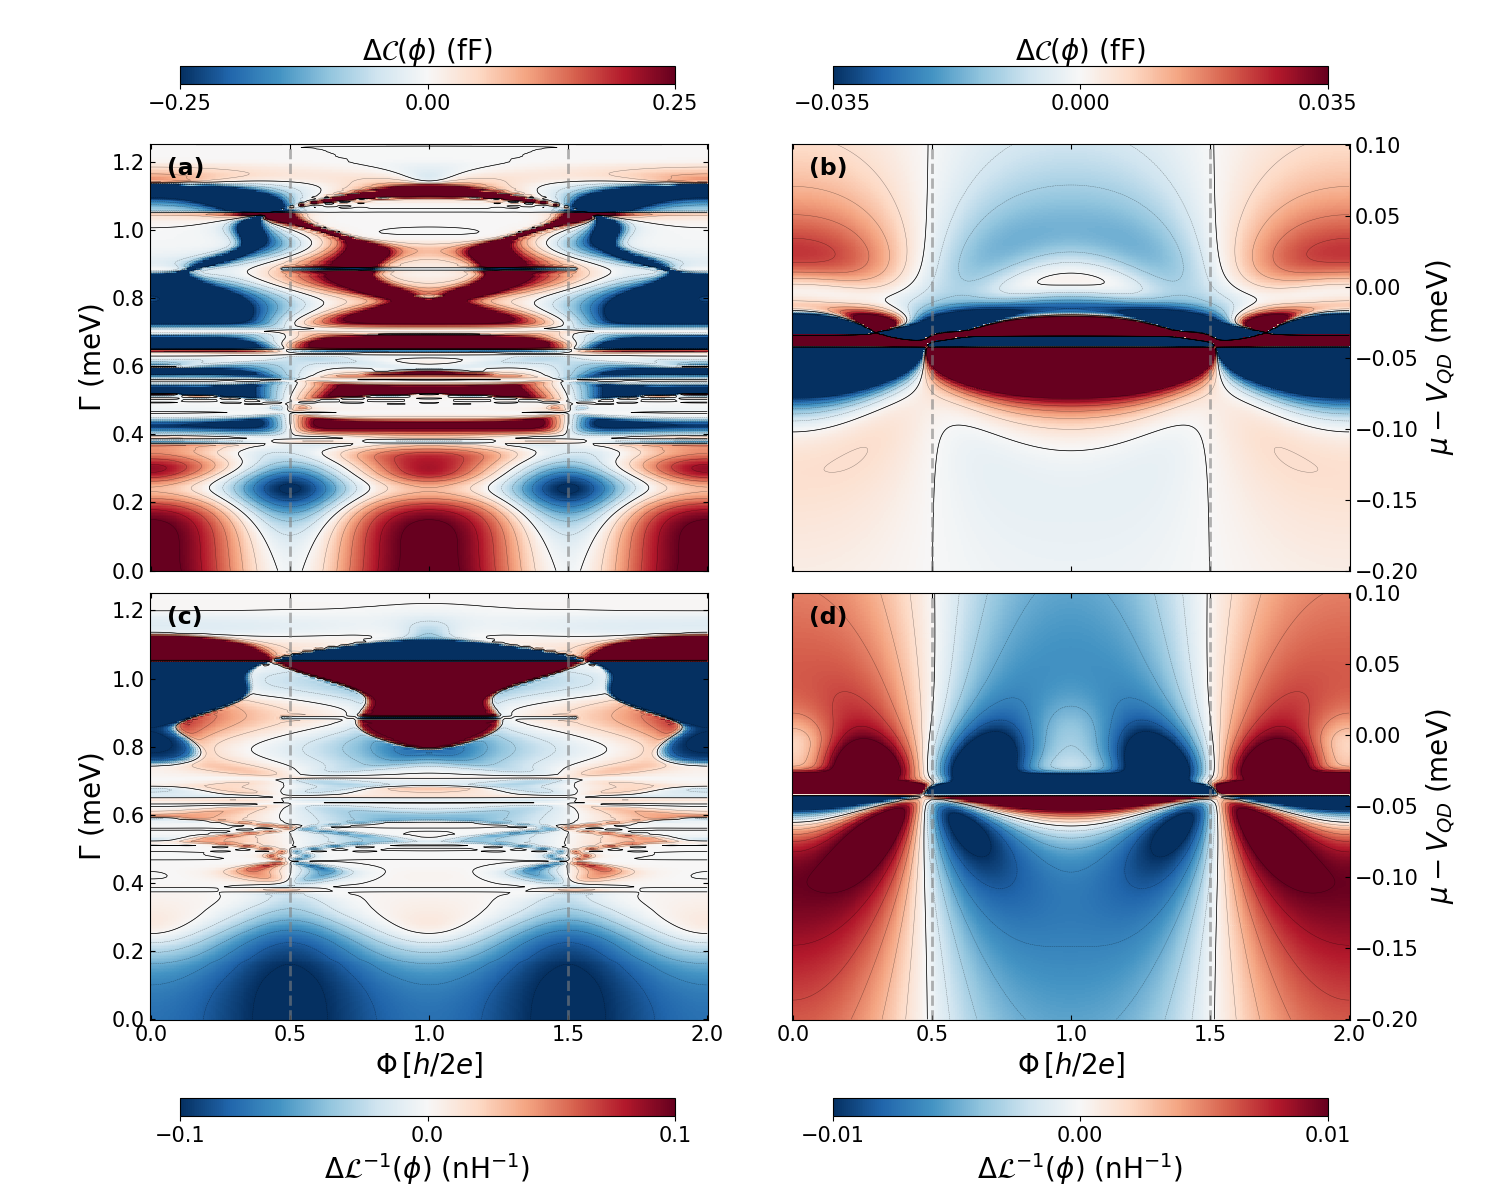

In [ ]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig = plt.figure(figsize=(15, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.05, wspace=0.15)

limit1 = 0.25
norm1 = TwoSlopeNorm(vmin=-limit1, vcenter=0.0, vmax=limit1)
limit2 = 0.10
norm2 = TwoSlopeNorm(vmin=-limit2, vcenter=0.0, vmax=limit2)
limit3 = 0.035
norm3 = TwoSlopeNorm(vmin=-limit3, vcenter=0.0, vmax=limit3)
limit4 = 0.01
norm4 = TwoSlopeNorm(vmin=-limit4, vcenter=0.0, vmax=limit4)

# ---------- top left: ΔC vs Γ ----------
ax_C_dens_Ez = fig.add_subplot(gs[0, 0])
pcm_C1 = ax_C_dens_Ez.pcolor(
    angles_fine, gam_range_loc_fine, Delta_C_fine.T,
    cmap='RdBu_r', norm=norm1, shading='nearest'
)

levels_C1 = np.linspace(-limit1, limit1, 13)
ax_C_dens_Ez.contour(
    angles_fine, gam_range_loc_fine, Delta_C_fine.T,
    levels=levels_C1, colors='k', linewidths=0.3, alpha=0.45
)
ax_C_dens_Ez.contour(
    angles_fine, gam_range_loc_fine, Delta_C_fine.T,
    levels=[0.0], colors='k', linewidths=0.5
)

ax_C_dens_Ez.set_ylabel(r'$\Gamma$ (meV)', fontsize=20)
plt.setp(ax_C_dens_Ez.get_xticklabels(), visible=False)

# ---------- bottom left: ΔL^{-1} vs Γ ----------
ax_L_dens_Ez = fig.add_subplot(gs[1, 0], sharex=ax_C_dens_Ez)
pcm_L1 = ax_L_dens_Ez.pcolor(
    angles_fine, gam_range_loc_fine, Delta_L_fine.T,
    cmap='RdBu_r', norm=norm2, shading='nearest'
)

levels_L1 = np.linspace(-limit2, limit2, 13)
ax_L_dens_Ez.contour(
    angles_fine, gam_range_loc_fine, Delta_L_fine.T,
    levels=levels_L1, colors='k', linewidths=0.3, alpha=0.45
)
ax_L_dens_Ez.contour(
    angles_fine, gam_range_loc_fine, Delta_L_fine.T,
    levels=[0.0], colors='k', linewidths=0.5
)

ax_L_dens_Ez.set_ylabel(r'$\Gamma$ (meV)', fontsize=20)
ax_L_dens_Ez.set_xlabel(r'$\Phi\,[h/2e]$', fontsize=20)

# ---------- top right: ΔC vs μ - V_QD ----------
ax_C_dens_vqd = fig.add_subplot(gs[0, 1], sharex=ax_C_dens_Ez)
pcm_C2 = ax_C_dens_vqd.pcolor(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_C_vqd_fine.T,
    cmap='RdBu_r', norm=norm3, shading='nearest'
)

levels_C2 = np.linspace(-limit3, limit3, 13)
ax_C_dens_vqd.contour(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_C_vqd_fine.T,
    levels=levels_C2, colors='k', linewidths=0.3, alpha=0.45
)
ax_C_dens_vqd.contour(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_C_vqd_fine.T,
    levels=[0.0], colors='k', linewidths=0.5
)

ax_C_dens_vqd.set_ylabel(r'$\mu - V_{QD}$ (meV)', fontsize=20)
plt.setp(ax_C_dens_vqd.get_xticklabels(), visible=False)

# ---------- bottom right: ΔL^{-1} vs μ - V_QD ----------
ax_L_dens_vqd = fig.add_subplot(gs[1, 1], sharex=ax_C_dens_Ez)
pcm_L2 = ax_L_dens_vqd.pcolor(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_L_vqd_fine.T,
    cmap='RdBu_r', norm=norm4, shading='nearest'
)

levels_L2 = np.linspace(-limit4, limit4, 13)
ax_L_dens_vqd.contour(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_L_vqd_fine.T,
    levels=levels_L2, colors='k', linewidths=0.3, alpha=0.45
)
ax_L_dens_vqd.contour(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_L_vqd_fine.T,
    levels=[0.0], colors='k', linewidths=0.5
)

ax_L_dens_vqd.set_ylabel(r'$\mu - V_{QD}$ (meV)', fontsize=20)
ax_L_dens_vqd.set_xlabel(r'$\Phi\,[h/2e]$', fontsize=20)

# ---------- shared formatting: ticks & panel labels ----------

# set the same xticks (2.0 periodicity) on the shared x-axis;
# all other axes that share x inherit them
ax_L_dens_Ez.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])

for ax in [ax_C_dens_Ez, ax_L_dens_Ez, ax_C_dens_vqd, ax_L_dens_vqd]:
    ax.tick_params(
        labelsize=15,
        direction='in',
        top=True, right=True, bottom=True, left=True
    )

# ---- Move right-column y-axis labels & ticks to the right ----

# Top right panel
ax_C_dens_vqd.yaxis.set_label_position("right")
ax_C_dens_vqd.yaxis.tick_right()

# Bottom right panel
ax_L_dens_vqd.yaxis.set_label_position("right")
ax_L_dens_vqd.yaxis.tick_right()

# =============================================================
# CLEAN, EXTERNAL COLORBARS FOR THE FOUR PLOTS
# =============================================================

# --- Top row colorbars (for ΔC) ---
cbar_ax_C_left  = fig.add_axes([0.12, 0.93, 0.33, 0.015])   # [left, bottom, width, height]
cbar_ax_C_right = fig.add_axes([0.555, 0.93, 0.33, 0.015])

cbar_C_left  = fig.colorbar(pcm_C1, cax=cbar_ax_C_left, orientation='horizontal')
cbar_C_right = fig.colorbar(pcm_C2, cax=cbar_ax_C_right, orientation='horizontal')

# Set ticks + label
for cb, lim in zip([cbar_C_left, cbar_C_right], [limit1, limit3]):
    cb.set_ticks([-lim, 0.0, lim])
    cb.ax.tick_params(labelsize=15)
    cb.set_label(r'$\Delta \mathcal{C}(\phi)$ (fF)', fontsize=20)
    cb.ax.xaxis.set_label_position('top')


# --- Bottom row colorbars (for ΔL^{-1}) ---
cbar_ax_L_left  = fig.add_axes([0.12, 0.07, 0.33, 0.015])
cbar_ax_L_right = fig.add_axes([0.555, 0.07, 0.33, 0.015])

cbar_L_left  = fig.colorbar(pcm_L1, cax=cbar_ax_L_left, orientation='horizontal')
cbar_L_right = fig.colorbar(pcm_L2, cax=cbar_ax_L_right, orientation='horizontal')

for cb, lim in zip([cbar_L_left, cbar_L_right], [limit2, limit4]):
    cb.set_ticks([-lim, 0.0, lim])
    cb.ax.tick_params(labelsize=15)
    cb.set_label(r'$\Delta \mathcal{L}^{-1}(\phi)$ (n$\mathrm{H}^{-1}$)', fontsize=20)

for ax in [ax_C_dens_Ez, ax_L_dens_Ez, ax_C_dens_vqd, ax_L_dens_vqd]:
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=2.0, alpha=0.6)
    ax.axvline(1.5, color='gray', linestyle='--', linewidth=2.0, alpha=0.6)


# panel labels: (a) top right, (b) top left, (c) bottom right, (d) bottom left
ax_C_dens_vqd.text(0.03, 0.97, '(b)', transform=ax_C_dens_vqd.transAxes,
                   fontsize=17, fontweight='bold', va='top', ha='left')
ax_C_dens_Ez.text(0.03, 0.97, '(a)', transform=ax_C_dens_Ez.transAxes,
                  fontsize=17, fontweight='bold', va='top', ha='left')
ax_L_dens_vqd.text(0.03, 0.97, '(d)', transform=ax_L_dens_vqd.transAxes,
                   fontsize=17, fontweight='bold', va='top', ha='left')
ax_L_dens_Ez.text(0.03, 0.97, '(c)', transform=ax_L_dens_Ez.transAxes,
                  fontsize=17, fontweight='bold', va='top', ha='left')

plt.subplots_adjust(left=0.10, right=0.9, top=0.88, bottom=0.15)

#plt.savefig("../Impedance_calc_paper/Plots/Weakly_dis_V0_03_sys_delta_C_L_Vqd_Ez_phi_density_plots.pdf")
plt.show()


In [ ]:
output_dir = "Paper_result_files/"
np.savetxt(output_dir+"_delta_capacitance_Ez_phi_551_mu_05_Gamma_066.txt", Delta_C_dens)
np.savetxt(output_dir+"_delta_capacitance_mu_vqd_phi_551_mu_05_Gamma_066.txt", Delta_C_dens_vqd)
np.savetxt(output_dir+"_delta_inductance_Ez_phi_P_551_mu_05_Gamma_066.txt", Delta_L_dens)
np.savetxt(output_dir+"_delta_inductance_mu_vqd_phi_D_551_mu_05_Gamma_066.txt", Delta_L_dens_vqd)

In [56]:
def worker_ts_sweep(w_avg, mu_loc, gam_range_loc, No_QD_loc, params):
    """Worker function to compute Topological_stability for a given tunnel strength"""
    p = deepcopy(params)
    p.w_left = p.w_right = w_avg
    Ts_gam_sweep = []
    for Ez0 in gam_range_loc:
        Ts_gam_sweep.append(Topological_stability(mu_loc, Ez0, No_QD_loc, p))
    return Ts_gam_sweep

tunnel_strength_range = np.logspace(-3.0, np.log10(0.5), V_QD_points_loc)
# Parallelize the outer loop (tunnel strength range)
Ts_sweep = Parallel(n_jobs=6, backend="loky")(
    delayed(worker_ts_sweep)(w_avg, mu_loc, gam_range_loc, No_QD_loc, deepcopy(params))
    for w_avg in tqdm(tunnel_strength_range)
)

100%|██████████| 100/100 [33:43<00:00, 20.23s/it]


In [ ]:
np.savetxt(output_dir+"_sys_Ts_sweep_lambda_Ez_mu_05_vqd_0551.txt", Ts_sweep)

In [58]:
from scipy.interpolate import RectBivariateSpline
Ts_sweep = np.array(Ts_sweep)

f = RectBivariateSpline(tunnel_strength_range, gam_range_loc, Ts_sweep)
gam_range_loc_fine = np.linspace(gam_low_loc, gam_high_loc, 450)
tunnel_strength_range_fine = np.logspace(-3.0, np.log10(0.5), 300)

Ts_sweep_fine = f(tunnel_strength_range_fine, gam_range_loc_fine)

/var/folders/48/y24539z12pz_600tsnssd6vr0000gn/T/ipykernel_2656/3176092824.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm", 256)


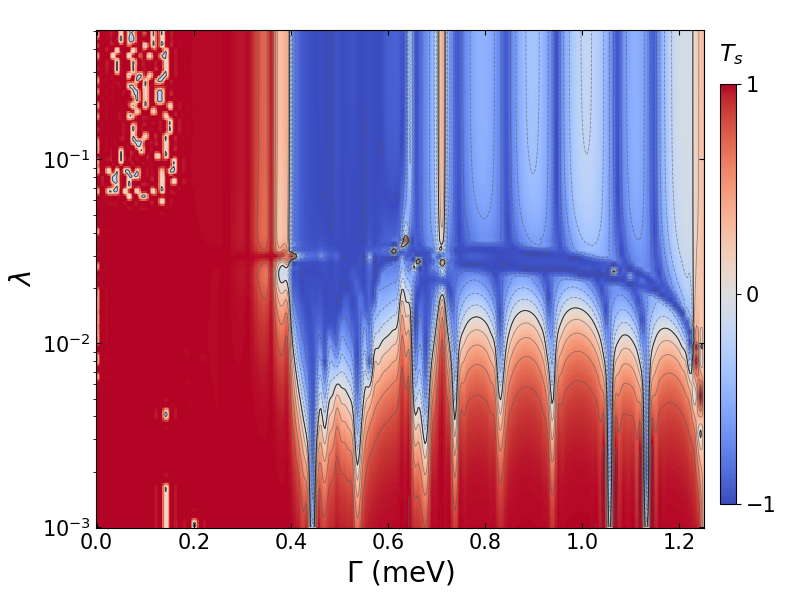

In [ ]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

fig, ax_Ts = plt.subplots(figsize=(8, 6))

# symmetric normalization around 0: negative = topo, positive = trivial
norm = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

# main density plot
pcm = ax_Ts.pcolormesh(
    gam_range_loc_fine,
    tunnel_strength_range_fine,
    Ts_sweep_fine,
    cmap="coolwarm",
    norm=norm,
    shading="nearest"
)

cmap = cm.get_cmap("coolwarm", 256)
cmap = ListedColormap(cmap(np.linspace(0.1, 0.93, 256)))

# contours: light grey structure + bold phase boundary at Ts = 0
levels_thin = np.linspace(-1.0, 1.0, 11)
ax_Ts.contour(
    gam_range_loc_fine[100:],
    tunnel_strength_range_fine,
    Ts_sweep_fine[:,100:],
    levels=levels_thin,
    colors="#585858",
    linewidths=0.6,
    alpha=0.6,
)
ax_Ts.contour(
    gam_range_loc_fine,
    tunnel_strength_range_fine,
    Ts_sweep_fine,
    levels=[0.0],                 # phase boundary (Ts = 0)
    colors="k",
    linewidths=0.7,
    alpha=0.7,
)

# axes formatting
ax_Ts.set_yscale("log")
ax_Ts.set_xlabel(r"$\Gamma$ (meV)", fontsize=20)
ax_Ts.set_ylabel(r"$\lambda$", fontsize=20)
ax_Ts.tick_params(
    labelsize=15,
    direction="in",
    top=True,
    right=True,
    bottom=True,
    left=True
)

# (optional) emphasize the usual Zeeman critical field if you want:
# ax_Ts.axvline(0.54, color="gray", linestyle="--", linewidth=1.0, alpha=0.6)

# external vertical colorbar on the right
plt.subplots_adjust(left=0.12, right=0.88, top=0.95, bottom=0.12)

cax = fig.add_axes([0.90, 0.16, 0.02, 0.70])  # [left, bottom, width, height]
cbar = fig.colorbar(pcm, cax=cax, orientation="vertical")
cbar.set_ticks([-1.0, 0.0, 1.0])
cbar.ax.tick_params(labelsize=15)
cbar.set_label(r"$T_s$", fontsize=17, rotation=0)
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.tick_right()
cbar.ax.yaxis.set_label_coords(0.7, 1.1)

#plt.savefig("../Impedance_calc_paper/Plots/Weakly_dis_V0_03_sys_Ts_lambda_Ez_density_plots.pdf")
plt.show()